<a href="https://colab.research.google.com/github/umangi003/airbnb-price-prediction/blob/dev/EDA%20Notebook/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Setup and load raw data**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_csv("listings.csv.gz")

print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total rows: 77679
Total columns: 90


##**Structure overview**

In [69]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            77679 non-null  int64  
 1   listing_url                                   77679 non-null  object 
 2   scrape_id                                     77679 non-null  int64  
 3   last_scraped                                  77679 non-null  object 
 4   source                                        77679 non-null  object 
 5   name                                          77679 non-null  object 
 6   description                                   74850 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   77678 non-null  object 
 9   host_id                                       77679 non-null 

##**Variables Types Breakdown**

In [70]:
dtype_counts = df.dtypes.value_counts()
print("Column data types:")
print(dtype_counts)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical/text columns ({len(categorical_cols)}): {categorical_cols}")

Column data types:
float64    37
object     29
int64      24
Name: count, dtype: int64

Numeric columns (61): ['id', 'scrape_id', 'neighborhood_overview', 'host_id', 'host_profile_id', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'neighbourhood', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of

In [71]:
df.head(3)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,price_quote_checkin_date,price_quote_checkout_date,price_quote_total_price,price_quote_price_per_night,price_quote_raw,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,https://www.airbnb.com/users/show/581233,1.462523e+18,https://www.airbnb.com/users/profile/146252253...,Frédéric,NaN,15.0,1.0,10.0,3.0,"Paris, France",I'm Fred. i'm 33 and I live in Paris ;)\n\nI l...,NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/db809...,NaN,1.0,NaN,NaN,t,t,NaN,Vaugirard,NaN,48.84950,2.28936,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Essentials"", ""Smoke alarm"", ""Cooking basics""...",$226.75,2026-06-27,2026-07-01,907.0,226.75,"{""quote"": {""taxes"": null, ""currency"": ""EUR"", ""...",4,1125,4,4,1125,1125,4.0,1125.0,NaN,t,21,51,63,63,2026-06-21,103,6,1,63,6,62,14059.0,2016-03-23,2026-05-28,4.83,4.88,4.62,4.90,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,https://www.airbnb.com/users/show/379042,1.462517e+18,https://www.airbnb.com/users/profile/146251699...,Edward Muriel,NaN,15.0,4.0,15.0,1.0,"Paris, France","We rent the second floor of our duplex, which ...",NaN,NaN,NaN,t,NaN,https://a0.muscache.com/im/pictures/user/d6dba...,NaN,3.0,NaN,NaN,t,t,NaN,Buttes-Montmartre,NaN,48.88474,2.36072,Entire rental unit,Entire home/apt,4,NaN,1 bath,2.0,NaN,"[""Wine glasses"", ""Oven"", ""Bed linens"", ""Books ...",NaN,NaN,NaN,NaN,NaN,NaN,3,750,3,3,750,750,3.0,750.0,NaN,t,0,0,0,0,2026-06-25,5,0,0,0,0,0,NaN,2024-07-29,2024-08-11,5.00,5.00,4.80,4.80,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,https://www.airbnb.com/users/show/584977,1.462523e+18,https://www.airbnb.com/users/profile/146252266...,Fabien,NaN,15.0,1.0,15.0,1.0,"Paris, France",Bienvenue :),NaN,NaN,NaN,f,NaN,https://a0.muscache.com/im/pictures/user/0cfae...,NaN,1.0,NaN,NaN,t,t,NaN,Buttes-Montmartre,NaN,48.89187

##**Summary Statistics for all numeric columns**

In [72]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,77679.0,7.518416e+17,6.063842e+17,3.109000e+03,3.589697e+07,9.265324e+17,1.205154e+18,1.709018e+18
scrape_id,77679.0,2.026062e+13,7.214890e+00,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13,2.026062e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,77679.0,5.655512e+15,9.740654e+16,2.626000e+03,1.978545e+07,8.048601e+07,3.956882e+08,1.708761e+18
host_profile_id,77419.0,1.470985e+18,2.705219e+16,1.462506e+18,1.462974e+18,1.466801e+18,1.469786e+18,1.712957e+18
...,...,...,...,...,...,...,...,...
calculated_host_listings_count,77679.0,2.338376e+01,8.775910e+01,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00,7.540000e+02
calculated_host_listings_count_entire_homes,77679.0,2.177093e+01,8.344289e+01,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,7.540000e+02
calculated_host_listings_count_private_rooms,77679.0,1.510112e+00,1.457611e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+02
calculated_host_listings_count_shared_rooms,77679.0,1.506199e-02,2.822079e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01


##**Missing Value Analysis**

In [73]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_report = missing_report[missing_report['missing_count'] > 0]
print(f"Columns with missing values: {len(missing_report)} out of {df.shape[1]}")
missing_report

Columns with missing values: 52 out of 90


,missing_count,missing_pct
neighborhood_overview,77679,100.00
host_since,77679,100.00
host_response_time,77679,100.00
host_thumbnail_url,77679,100.00
host_acceptance_rate,77679,100.00
host_response_rate,77679,100.00
host_verifications,77679,100.00
neighbourhood,77679,100.00
host_total_listings_count,77679,100.00
host_neighbourhood,77679,100.00


###Visualize Missingness

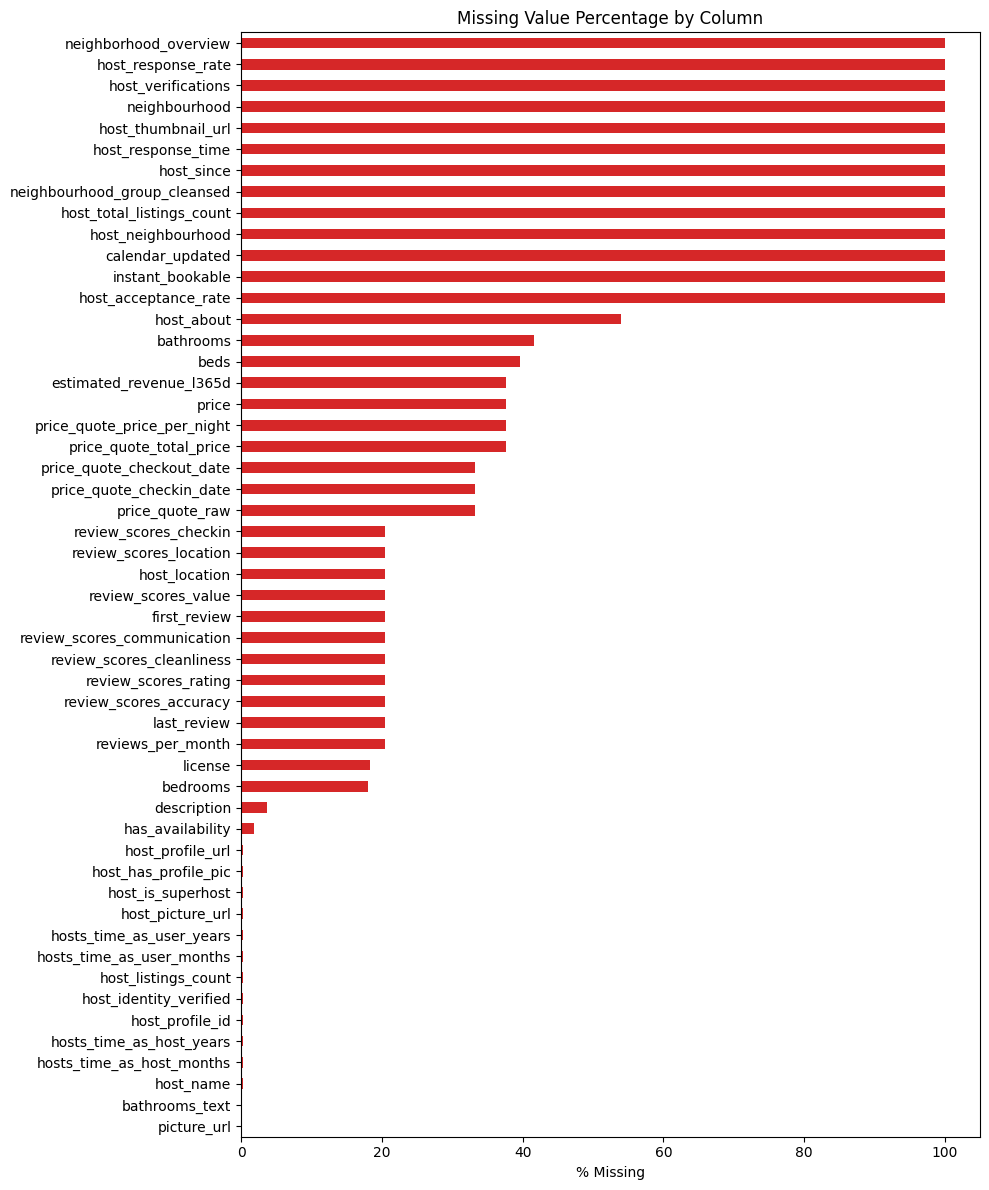

In [74]:
plt.figure(figsize=(10, 12))
missing_report['missing_pct'].sort_values().plot(kind='barh', color='#d62728')
plt.title('Missing Value Percentage by Column')
plt.xlabel('% Missing')
plt.tight_layout()
plt.savefig('missing_values_overview.png', dpi=150)
plt.show()

##**Duplicated Records Analysis**

###Exact Duplicate Rows

In [ ]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows (all columns identical): {exact_dupes}")

Exact duplicate rows (all columns identical): 0


###Duplicates Listing IDs


In [76]:
id_dupes = df['id'].duplicated().sum()
print(f"Duplicate listing IDs: {id_dupes}")
print("(Each listing ID should be unique — this confirms whether the scrape has re-listed duplicates.)")

Duplicate listing IDs: 0
(Each listing ID should be unique — this confirms whether the scrape has re-listed duplicates.)


###Fuzzy Duplicate Check

In [77]:
fuzzy_dupe_mask = df.duplicated(subset=['host_id', 'latitude', 'longitude', 'price'], keep=False)
fuzzy_dupes = fuzzy_dupe_mask.sum()
print(f"Rows involved in fuzzy duplicates (same host+location+price): {fuzzy_dupes}")

if fuzzy_dupes > 0:
    display_cols = ['id', 'host_id', 'name', 'latitude', 'longitude', 'price']
    print(df[fuzzy_dupe_mask][display_cols].sort_values('host_id').head(10))

Rows involved in fuzzy duplicates (same host+location+price): 1061
                        id   host_id  \
15402             26548158    727684   
15982             27102666    727684   
474                 691613   3398366   
475                 691913   3398366   
36921   896620440204554730   5438903   
48146  1084113293438175337   5438903   
68287  1491335934032699113   7546158   
68309  1491863777682346218   7546158   
20183             37140487  10916245   
23161             43969632  10916245   

                                                  name   latitude  longitude  \
15402        A room in the most convivial neighborhood  48.863610   2.380680   
15982               An authentic parisian neighborhood  48.863610   2.380680   
474    Studio LOFT - Opera- Grands Boulevards district  48.873120   2.344610   
475    Studio  loft style apt. in the heart of the 9th  48.873120   2.344610   
36921                  Studio with Eiffel Tower view 1  48.841542   2.314424   
48146       

##**Investigate Outliers & Unusual Observations**

###Clean Price for Analysis

In [78]:
df['price_clean'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
print(df['price_clean'].describe())

count    48402.000000
mean       321.230271
std        832.551387
min          3.200000
25%        131.330000
50%        205.500000
75%        342.000000
max      97003.050000
Name: price_clean, dtype: float64


###Price Outliers

In [79]:
print(df['price_clean'].quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0]))

0.900      577.6530
0.950      842.3925
0.990     1874.9800
0.995     2974.9375
0.999     8000.0000
1.000    97003.0500
Name: price_clean, dtype: float64


###Outliers in other key numeric fields

In [80]:
outlier_cols = ['minimum_nights', 'maximum_nights', 'availability_365', 'number_of_reviews']

for col in outlier_cols:
    print(f"\n--- {col} ---")
    print(df[col].describe())
    print("Top 5 highest values:")
    print(df[col].sort_values(ascending=False).head(5).values)


--- minimum_nights ---
count    77679.000000
mean        36.846947
std        100.510306
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1000.000000
Name: minimum_nights, dtype: float64
Top 5 highest values:
[1000 1000  999  730  729]

--- maximum_nights ---
count    7.767900e+04
mean     8.344804e+04
std      1.334544e+07
min      1.000000e+00
25%      6.000000e+01
50%      3.650000e+02
75%      1.125000e+03
max      2.147484e+09
Name: maximum_nights, dtype: float64
Top 5 highest values:
[2147483647 2147483647 2147483647       1125       1125]

--- availability_365 ---
count    77679.000000
mean       136.729412
std        135.064704
min          0.000000
25%          0.000000
50%         89.000000
75%        269.000000
max        365.000000
Name: availability_365, dtype: float64
Top 5 highest values:
[365 365 365 365 365]

--- number_of_reviews ---
count    77679.000000
mean        30.952626
std         66.999564
min          0.00000

###Validate against domain Expectations

In [81]:
invalid_price = (df['price_clean'] <= 0).sum()
print(f"Listings with price <= 0: {invalid_price}")

# Paris is roughly lat 48.80–48.92, long 2.22–2.47
invalid_lat = ((df['latitude'] < 48.80) | (df['latitude'] > 48.92)).sum()
invalid_long = ((df['longitude'] < 2.22) | (df['longitude'] > 2.47)).sum()
print(f"Listings with latitude outside expected Paris range: {invalid_lat}")
print(f"Listings with longitude outside expected Paris range: {invalid_long}")

Listings with price <= 0: 0
Listings with latitude outside expected Paris range: 0
Listings with longitude outside expected Paris range: 0


##**Examine Class Imbalance**

###Room Type Imbalance

In [82]:
room_dist = df['room_type'].value_counts()
room_dist_pct = df['room_type'].value_counts(normalize=True) * 100
print(pd.DataFrame({'count': room_dist, 'percentage': room_dist_pct.round(2)}))

                 count  percentage
room_type                         
Entire home/apt  69265       89.17
Private room      7858       10.12
Hotel room         410        0.53
Shared room        146        0.19


###Neighbourhood Imbalance

In [83]:
print(f"Number of unique neighbourhoods: {df['neighbourhood_cleansed'].nunique()}")
nbhd_dist = df['neighbourhood_cleansed'].value_counts(normalize=True) * 100
print(nbhd_dist.round(2))

Number of unique neighbourhoods: 20
neighbourhood_cleansed
Buttes-Montmartre      10.47
Popincourt              8.88
Vaugirard               8.01
Entrepôt                6.86
Batignolles-Monceau     6.60
Passy                   6.20
Buttes-Chaumont         5.42
Ménilmontant            5.31
Opéra                   4.70
Temple                  4.52
Reuilly                 4.07
Bourse                  3.73
Observatoire            3.61
Panthéon                3.37
Élysée                  3.31
Hôtel-de-Ville          3.24
Gobelins                3.22
Luxembourg              3.09
Palais-Bourbon          2.99
Louvre                  2.40
Name: proportion, dtype: float64


###Visualize Class Imbalance

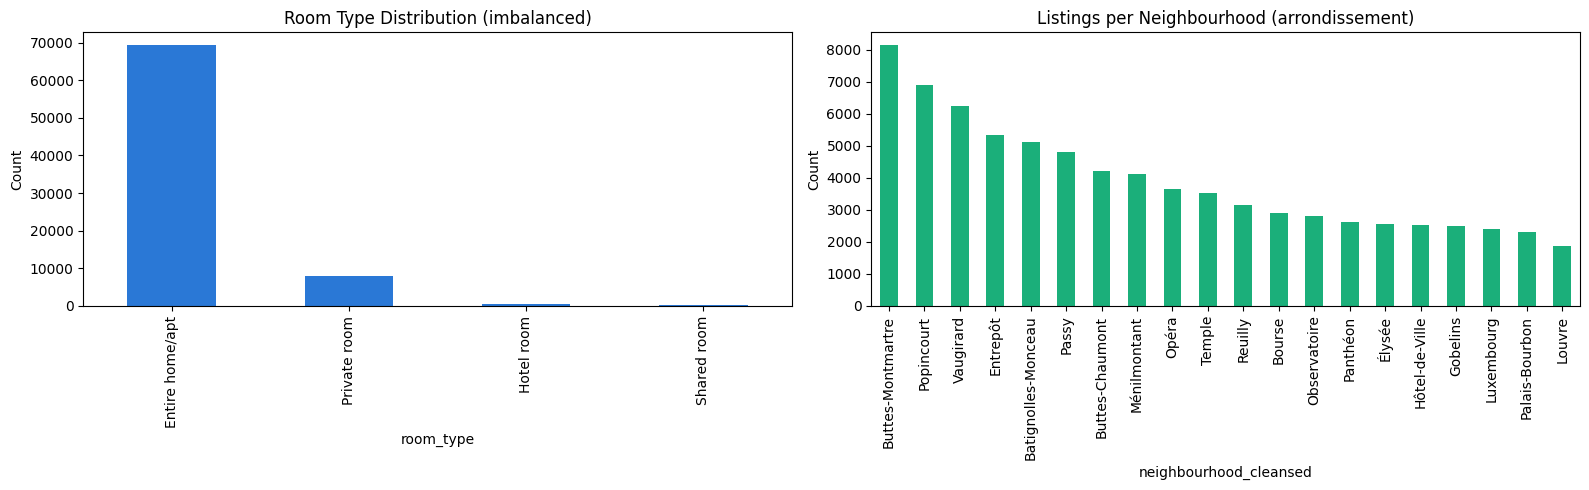

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df['room_type'].value_counts().plot(kind='bar', ax=axes[0], color='#2a78d6')
axes[0].set_title('Room Type Distribution (imbalanced)')
axes[0].set_ylabel('Count')

df['neighbourhood_cleansed'].value_counts().plot(kind='bar', ax=axes[1], color='#1baf7a')
axes[1].set_title('Listings per Neighbourhood (arrondissement)')
axes[1].set_ylabel('Count')
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150)
plt.show()

In [85]:
# Room-type counts
df['room_type'].value_counts(dropna=False)

,count
room_type,
Entire home/apt,69265
Private room,7858
Hotel room,410
Shared room,146


In [86]:
# Neighbourhood counts
df['neighbourhood_cleansed'].value_counts(dropna=False)

,count
neighbourhood_cleansed,
Buttes-Montmartre,8131
Popincourt,6899
Vaugirard,6224
Entrepôt,5330
Batignolles-Monceau,5128
Passy,4817
Buttes-Chaumont,4211
Ménilmontant,4124
Opéra,3651


##**Visualize Important Distributions & Relationships**

###Price Distribution

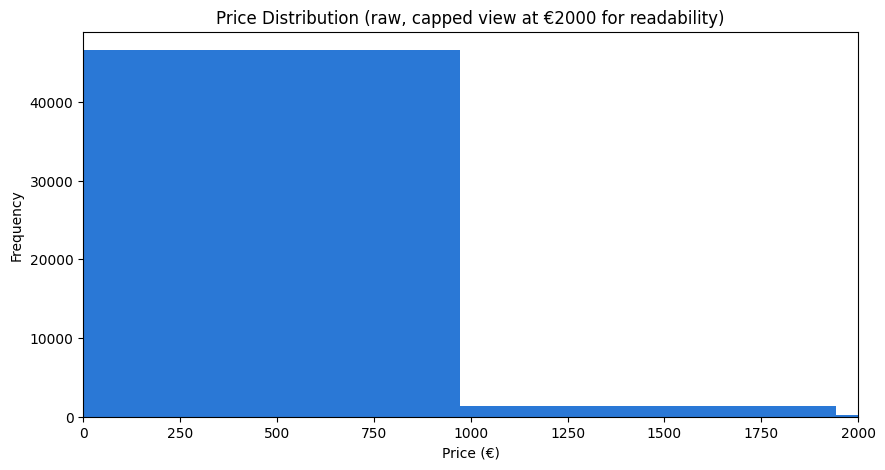

In [87]:
plt.figure(figsize=(10, 5))
plt.hist(df['price_clean'].dropna(), bins=100, color='#2a78d6')
plt.xlim(0, 2000)
plt.title('Price Distribution (raw, capped view at €2000 for readability)')
plt.xlabel('Price (€)')
plt.ylabel('Frequency')
plt.savefig('price_distribution_raw.png', dpi=150)
plt.show()

### Accommodate vs Price

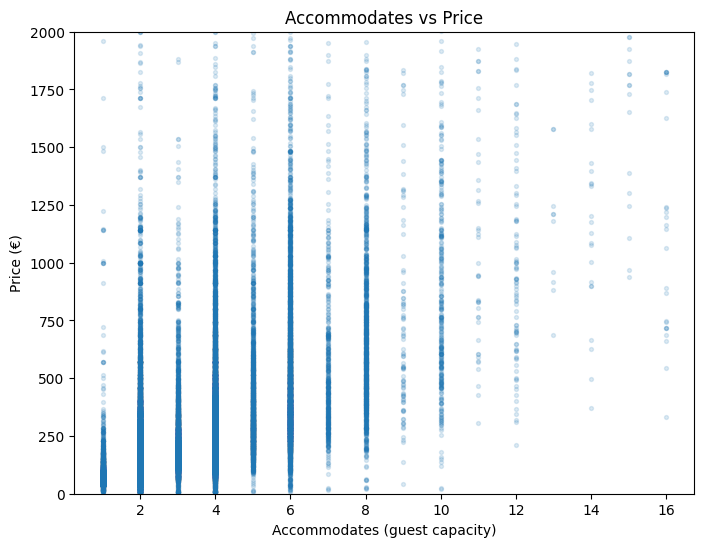

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(df['accommodates'], df['price_clean'], alpha=0.15, s=8)
plt.ylim(0, 2000)
plt.title('Accommodates vs Price')
plt.xlabel('Accommodates (guest capacity)')
plt.ylabel('Price (€)')
plt.savefig('accommodates_vs_price.png', dpi=150)
plt.show()

###Geographic Price Map

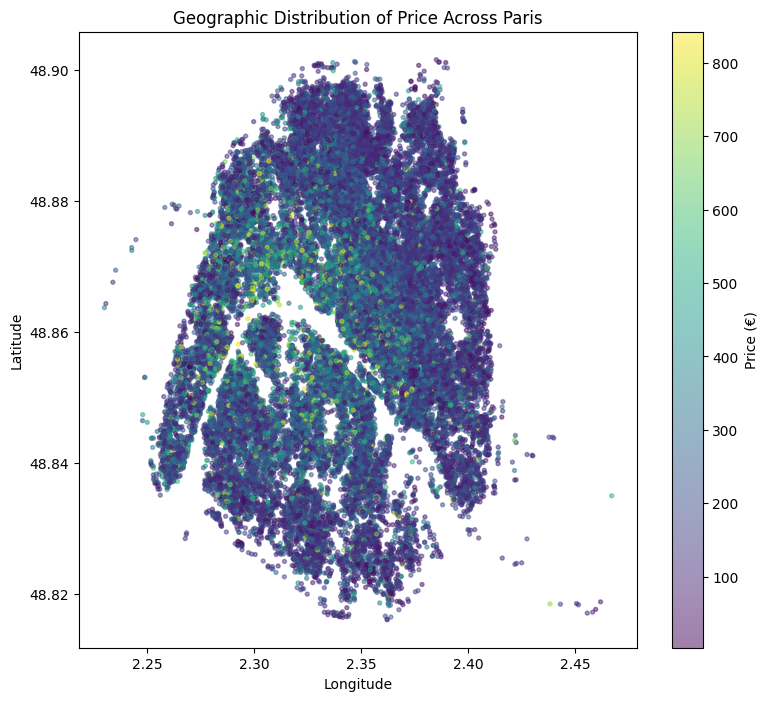

In [89]:
plt.figure(figsize=(9, 8))
sample = df[df['price_clean'] < df['price_clean'].quantile(0.95)]  # exclude extreme prices for a readable color scale
sc = plt.scatter(sample['longitude'], sample['latitude'], c=sample['price_clean'],
                  cmap='viridis', s=8, alpha=0.5)
plt.colorbar(sc, label='Price (€)')
plt.title('Geographic Distribution of Price Across Paris')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.savefig('geographic_price_distribution.png', dpi=150)
plt.show()

In [90]:
import folium
from folium.plugins import MarkerCluster, HeatMap

center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',attr='OpenTopoMap')

marker_cluster = MarkerCluster().add_to(m)

sample = df.sample(2000, random_state=42) if len(df) > 2000 else df

for _, row in sample.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        popup=f"{row['neighbourhood_cleansed']}: €{row['price_clean']:.0f}" if pd.notna(row['price_clean']) else row['neighbourhood_cleansed'],
        color='blue',
        fill=True
    ).add_to(marker_cluster)

m

### Correlation Heatmap(numeric features vs price)

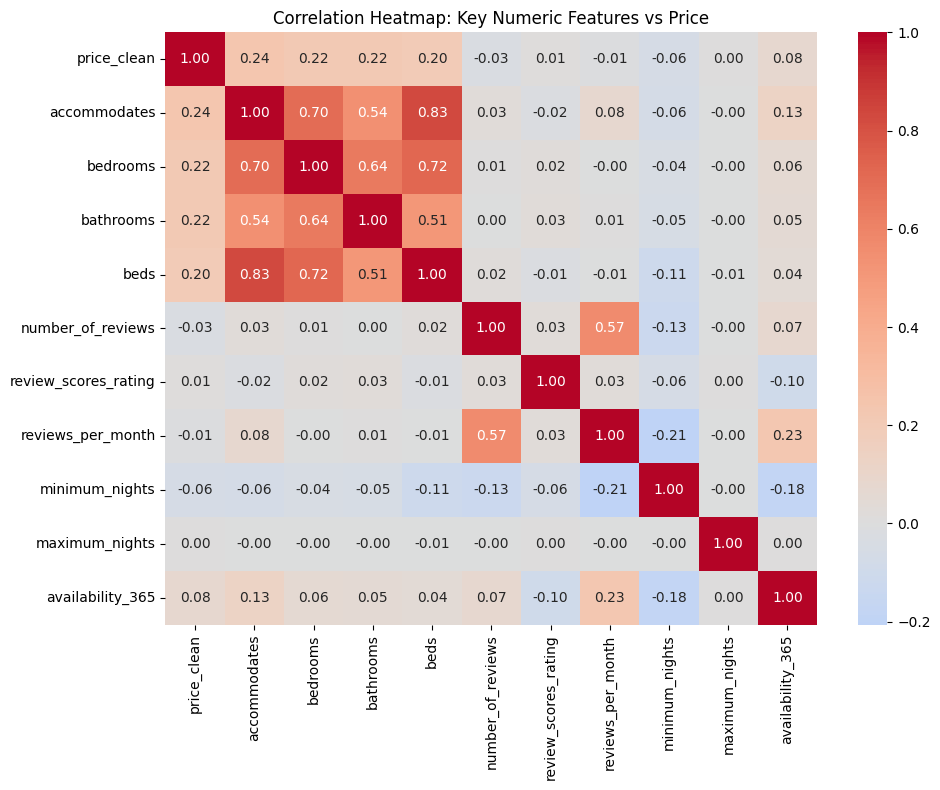

In [91]:
num_cols_for_corr = ['price_clean', 'accommodates', 'bedrooms', 'bathrooms', 'beds',
                       'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
                       'minimum_nights', 'maximum_nights', 'availability_365']

corr = df[num_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Key Numeric Features vs Price')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [94]:
price_corr = corr['price_clean'].drop('price_clean').sort_values(ascending=False)
print("Feature correlation with price (strongest to weakest):")
print(price_corr)

Feature correlation with price (strongest to weakest):
accommodates            0.239060
bathrooms               0.217820
bedrooms                0.217408
beds                    0.198242
availability_365        0.080866
review_scores_rating    0.012228
maximum_nights          0.001984
reviews_per_month      -0.010460
number_of_reviews      -0.029479
minimum_nights         -0.057626
Name: price_clean, dtype: float64


##**Identifying Potential Data Leakage and Check How It will be Prevented**

### Check for Leakage-Risk Columns

In [92]:
leakage_candidates = [c for c in df.columns if 'price_quote' in c.lower()]
print("Columns identified as potential leakage risks (derived from live price at scrape time):")
print(leakage_candidates)

# Confirm they correlate suspiciously highly with the target
if leakage_candidates:
    for col in leakage_candidates:
        if df[col].dtype in [np.float64, np.int64]:
            print(f"{col} correlation with price_clean: {df[[col, 'price_clean']].corr().iloc[0,1]:.4f}")

Columns identified as potential leakage risks (derived from live price at scrape time):
['price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw']
price_quote_total_price correlation with price_clean: 0.6285
price_quote_price_per_night correlation with price_clean: 1.0000


##**Consolidated Findings Printout**

In [95]:
print("=" * 60)
print("STAGE 3 EDA — KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"1. Dataset size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"2. Missing target (price): {df['price'].isnull().sum()} rows ({df['price'].isnull().mean()*100:.2f}%)")
print(f"3. Exact duplicate rows: {exact_dupes}")
print(f"4. Duplicate listing IDs: {id_dupes}")
print(f"5. Fuzzy duplicates (host+location+price): {fuzzy_dupes}")
print(f"6. Price outlier max: €{df['price_clean'].max():,.2f} (99th percentile: €{df['price_clean'].quantile(0.99):,.2f})")
print(f"7. Class imbalance — dominant room type: {room_dist.idxmax()} ({room_dist_pct.max():.1f}%)")
print(f"8. Strongest price correlation: {price_corr.index[0]} ({price_corr.iloc[0]:.3f})")
print(f"9. Leakage risk columns found: {leakage_candidates}")
print(f"10. Invalid geographic coordinates: {invalid_lat + invalid_long}")

STAGE 3 EDA — KEY FINDINGS SUMMARY
1. Dataset size: 77679 rows, 91 columns
2. Missing target (price): 29277 rows (37.69%)
3. Exact duplicate rows: 0
4. Duplicate listing IDs: 0
5. Fuzzy duplicates (host+location+price): 1061
6. Price outlier max: €97,003.05 (99th percentile: €1,874.98)
7. Class imbalance — dominant room type: Entire home/apt (89.2%)
8. Strongest price correlation: accommodates (0.239)
9. Leakage risk columns found: ['price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw']
10. Invalid geographic coordinates: 0
